<a href="https://colab.research.google.com/github/dilanmano20010-design/Teoria-juegos-decisiones-consumidor/blob/main/investigacion_mercados_financieros_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Investigación Cuantitativa de Mercados Financieros Globales Contemporáneos
### Estudio Empírico Multiactivo con Extracción en Tiempo Real desde Internet (Yahoo Finance)

---
* **Autor**: **Dilan Alexander Manosalvas Andrade**
* **Sitio Web / Portafolio**: [https://econometricis.vercel.app/](https://econometricis.vercel.app/)
* **Plataforma de Ejecución**: Google Colab / Python para Análisis Financiero y Econometría
* **Clases de Activos Analizadas**:
  * **Renta Variable**: S&P 500 (`^GSPC`), Nasdaq 100 (`^NDX`), Russell 2000 (`^RUT`)
  * **Las 7 Magníficas (AI & Big Tech)**: NVIDIA (`NVDA`), Microsoft (`MSFT`), Apple (`AAPL`), Amazon (`AMZN`), Alphabet (`GOOGL`), Meta (`META`), Tesla (`TSLA`)
  * **Renta Fija y Tasas**: Rendimiento del Bono del Tesoro de EE.UU. a 10 Años (`^TNX`)
  * **Materias Primas / Commodities**: Oro Spot (`GC=F`), Petróleo Crudo WTI (`CL=F`)
  * **Divisas**: Índice Dólar estadounidense (`DX-Y.NYB`), EUR/USD (`EURUSD=X`)
  * **Criptoactivos**: Bitcoin (`BTC-USD`), Ethereum (`ETH-USD`)
  * **Métricas de Incertidumbre**: Índice de Volatilidad VIX (`^VIX`)

---
###  Objetivos de la Investigación:
1. **Evaluar el rendimiento comparativo multiactivo** mediante precios normalizados a Base 100.
2. **Estudiar la distribución de rendimientos** y comprobar empíricamente la existencia de asimetría (*skewness*) y curtosis (*fat tails* / colas pesadas).
3. **Calcular métricas de riesgo fundamentales**: Volatilidad Anualizada, Ratio de Sharpe, Ratio de Sortino, Máximo Drawdown (*Peak-to-Trough*) y Valor en Riesgo (*Value at Risk* - VaR al 95% y 99%).
4. **Analizar la dinámica de correlación cruzada y correlaciones rodantes** para contrastar la hipótesis de activos de refugio (Oro vs. Bitcoin vs. Dólar).
5. **Examinar la concentración de mercado** impulsada por el auge de la Inteligencia Artificial frente al mercado amplio.
6. **Desarrollar gráficos interactivos con Plotly**: Velas japonesas, dashboards dinámicos multiactivo con selectores de rango temporal y **modelado tridimensional (3D)** de la Frontera Eficiente de Markowitz (Monte Carlo 3D) y la Superficie 3D de Volatilidad.


## 1. Configuración del Entorno y Dependencias
En Google Colab, las librerías científicas como `numpy`, `pandas` y `matplotlib` están preinstaladas. Instalamos `yfinance` para la consulta directa a las bases de datos abiertas de Yahoo Finance y `plotly` para visualizaciones interactivas de grado analítico.


In [ ]:
# Instalación de librerías en Google Colab
!pip install -q yfinance plotly statsmodels seaborn


## 2. Importación de Librerías y Configuración Visual
Configuramos los parámetros de visualización gráfica en alta resolución con estilos modernos para facilitar la interpretación de patrones financieros.


In [ ]:
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import yfinance as yf
from datetime import datetime, timedelta
from scipy import stats

# Configuración estética para gráficos estáticos
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("✅ Entorno listo para la investigación.")
print("Versión de Python:", sys.version.split()[0])
print("Versión de Pandas:", pd.__version__)
print("Versión de yfinance:", yf.__version__)


✅ Entorno listo para la investigación.
Versión de Python: 3.13.15
Versión de Pandas: 2.2.3
Versión de yfinance: 0.2.66


## 3. Universo Multiactivo y Pipeline de Extracción Automatizada
Definimos los tickers representativos de cada mercado financiero. Los datos se descargan de forma automática desde hace 3 años hasta la fecha de ejecución del cuaderno en vivo.


In [ ]:
# Diccionario multiactivo
ASSETS = {
    # Índices Bursátiles Globales
    '^GSPC': 'S&P 500',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000 (Small Caps)',

    # Las 7 Magníficas del Sector Tecnológico
    'NVDA': 'NVIDIA',
    'MSFT': 'Microsoft',
    'AAPL': 'Apple',
    'AMZN': 'Amazon',
    'GOOGL': 'Alphabet (Google)',
    'META': 'Meta Platforms',
    'TSLA': 'Tesla',

    # Renta Fija y Tasas de Interés
    '^TNX': 'Bono Tesoro EE.UU. 10Y (Yield)',

    # Materias Primas / Commodities
    'GC=F': 'Oro (Gold Futures)',
    'CL=F': 'Petróleo Crudo WTI',

    # Divisas
    'DX-Y.NYB': 'Índice Dólar (DXY)',
    'EURUSD=X': 'EUR / USD',

    # Criptoactivos
    'BTC-USD': 'Bitcoin (BTC)',
    'ETH-USD': 'Ethereum (ETH)',

    # Métrica de Volatilidad Implícita
    '^VIX': 'Índice de Volatilidad VIX'
}

# Rango temporal: Últimos 3 años hasta el día de hoy
END_DATE = datetime.today()
START_DATE = END_DATE - timedelta(days=3 * 365)

print(f"Descargando datos históricos desde {START_DATE.strftime('%Y-%m-%d')} hasta {END_DATE.strftime('%Y-%m-%d')}...")

raw_data = yf.download(
    tickers=list(ASSETS.keys()),
    start=START_DATE.strftime('%Y-%m-%d'),
    end=END_DATE.strftime('%Y-%m-%d'),
    interval='1d',
    auto_adjust=True,
    progress=True
)

# Extracción de precios de cierre
if 'Close' in raw_data.columns:
    df_prices = raw_data['Close'].copy()
else:
    df_prices = raw_data.copy()

# Renombrar columnas para claridad
df_prices = df_prices.rename(columns=ASSETS)

# Limpieza: Forward-fill para alinear calendarios (Cripto opera 24/7; mercados tradicionales cierran fines de semana)
df_prices = df_prices.ffill().dropna()

print(f"\nBase de datos estructurada con éxito: {df_prices.shape[0]} ruedas operativas y {df_prices.shape[1]} activos.")
display(df_prices.tail(5))


[***********           22%                       ]  4 of 18 completed

Descargando datos históricos desde 2023-09-10 hasta 2026-09-09...


[*********************100%***********************]  18 of 18 completed



Base de datos estructurada con éxito: 1095 ruedas operativas y 18 activos.


Ticker,Apple,Amazon,Bitcoin (BTC),Petróleo Crudo WTI,Índice Dólar (DXY),Ethereum (ETH),EUR / USD,Oro (Gold Futures),Alphabet (Google),Meta Platforms,Microsoft,NVIDIA,Tesla,S&P 500,Nasdaq 100,Russell 2000 (Small Caps),Bono Tesoro EE.UU. 10Y (Yield),Índice de Volatilidad VIX
Date,,,,,,,,,,,,,,,,,,
2026-09-05,319.970001,258.510010,79823.867188,91.480003,99.160004,2480.735596,1.162831,4429.799805,338.459991,616.77002,499.700012,230.360001,354.079987,7718.600098,29544.150391,2975.649902,4.784,14.53
2026-09-06,319.970001,258.510010,80350.046875,91.480003,99.160004,2514.548828,1.162831,4429.799805,338.459991,616.77002,499.700012,230.360001,354.079987,7718.600098,29544.150391,2975.649902,4.784,14.53
2026-09-07,319.970001,258.510010,79115.851562,91.480003,99.160004,2490.958008,1.161400,4429.799805,338.459991,616.77002,499.700012,230.360001,354.079987,7718.600098,29544.150391,2975.649902,4.784,15.30
2026-09-08,316.220001,256.970001,78438.578125,93.029999,98.839996,2484.941406,1.162764,4393.899902,338.359985,613.47998,493.950012,225.729996,368.160004,7673.520020,29507.699219,2960.199951,4.806,15.72
2026-09-09,316.220001,256.970001,78438.578125,93.029999,98.839996,2484.941406,1.162737,4393.899902,338.359985,613.47998,493.950012,225.729996,368.160004,7673.520020,29507.699219,2960.199951,4.806,15.72


## 4. Análisis Exploratorio de Precios y Normalización (Base 100)
Para comparar de forma justa el desempeño relativo entre activos con cotizaciones nominales dispares (acciones, onzas de oro, barriles de crudo o criptoactivos), normalizamos las series a **Base 100** al inicio del periodo:
$$P_t^{\text{norm}} = \frac{P_t}{P_0} \times 100$$
Calculamos adicionalmente los rendimientos porcentuales diarios simples:
$$R_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$


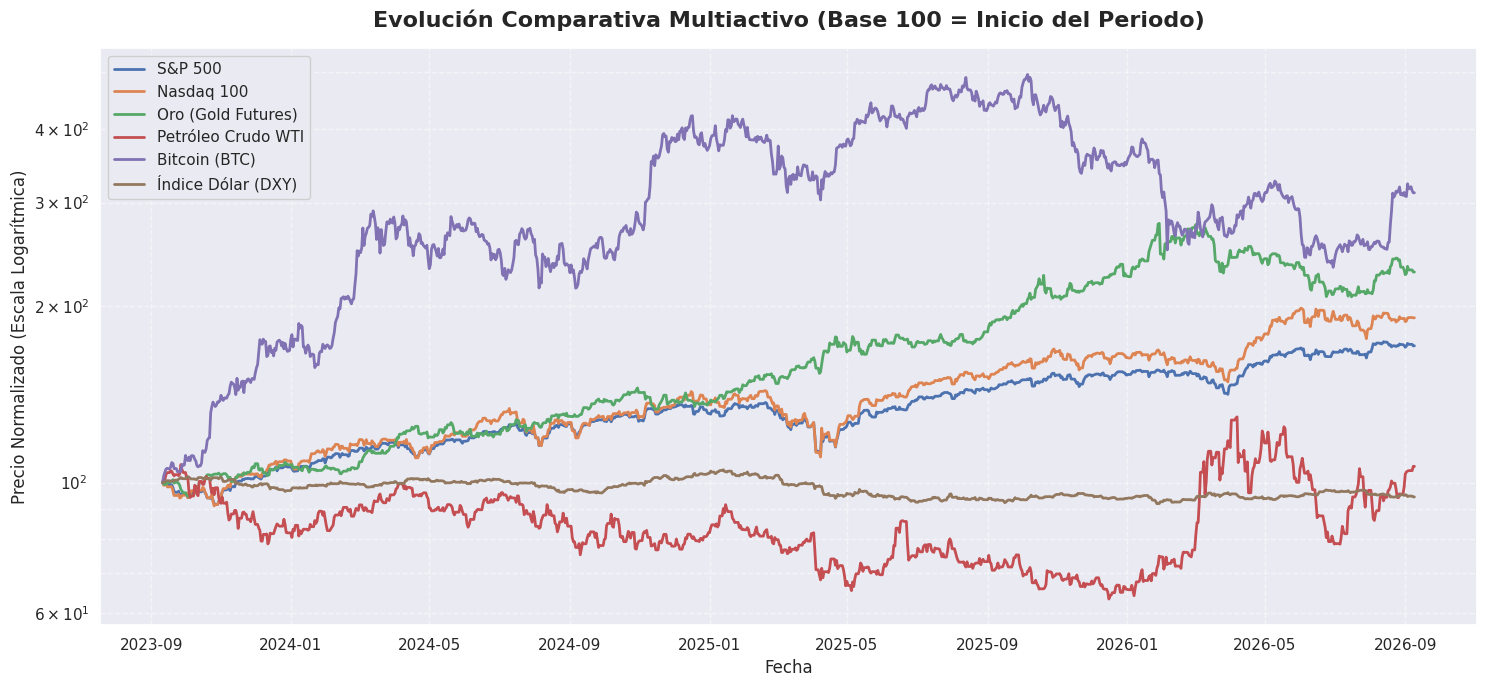

In [ ]:
# Precios normalizados a Base 100
df_norm = (df_prices / df_prices.iloc[0]) * 100

# Retornos diarios simples
df_returns = df_prices.pct_change().dropna()

# Selección de macroactivos para el gráfico comparativo
macro_assets = ['S&P 500', 'Nasdaq 100', 'Oro (Gold Futures)', 'Petróleo Crudo WTI', 'Bitcoin (BTC)', 'Índice Dólar (DXY)']

plt.figure(figsize=(15, 7))
for asset in macro_assets:
    if asset in df_norm.columns:
        plt.plot(df_norm.index, df_norm[asset], label=asset, linewidth=2)

plt.title("Evolución Comparativa Multiactivo (Base 100 = Inicio del Periodo)", fontsize=16, pad=15)
plt.xlabel("Fecha")
plt.ylabel("Precio Normalizado (Escala Logarítmica)")
plt.yscale('log')
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 5. Momentos Estadísticos y Análisis de Colas Pesadas (*Fat Tails*)
En la econometría financiera tradicional se suele asumir normalidad en los retornos. Sin embargo, en la práctica los mercados presentan **asimetría** y **curtosis excesiva** (*leptocurtosis*):
* **Rendimiento Anualizado**: $\mu_{\text{anual}} = \mu_{\text{diario}} \times 252$
* **Volatilidad Anualizada**: $\sigma_{\text{anual}} = \sigma_{\text{diario}} \times \sqrt{252}$
* **Asimetría (*Skewness*)**: Mide si los desvíos son más frecuentes hacia pérdidas o ganancias.
* **Curtosis (*Kurtosis*)**: Mide la frecuencia de eventos extremos frente a una campana de Gauss ($	ext{Curtosis} > 3$).


In [ ]:
summary_stats = pd.DataFrame(index=df_returns.columns)
summary_stats['Rendimiento Anualizado (%)'] = (df_returns.mean() * 252) * 100
summary_stats['Volatilidad Anualizada (%)'] = (df_returns.std() * np.sqrt(252)) * 100
summary_stats['Asimetría (Skewness)'] = df_returns.skew()
summary_stats['Curtosis (Kurtosis)'] = df_returns.kurtosis()
summary_stats['Retorno Acumulado Total (%)'] = ((df_prices.iloc[-1] / df_prices.iloc[0]) - 1) * 100

summary_stats = summary_stats.round(2).sort_values(by='Rendimiento Anualizado (%)', ascending=False)

print("📊 Tabla de Momentos Estadísticos Cuantitativos:")
display(summary_stats)


📊 Tabla de Momentos Estadísticos Cuantitativos:


,Rendimiento Anualizado (%),Volatilidad Anualizada (%),Asimetría (Skewness),Curtosis (Kurtosis),Retorno Acumulado Total (%)
Ticker,,,,,
Índice de Volatilidad VIX,60.57,112.02,2.67,23.24,13.91
NVIDIA,44.66,38.91,0.34,8.55,400.58
Bitcoin (BTC),33.82,39.15,0.35,3.52,211.73
Ethereum (ETH),26.05,55.48,0.62,4.66,60.15
Alphabet (Google),24.27,25.37,0.36,8.20,149.47
Meta Platforms,20.87,31.07,1.23,18.12,101.22
Oro (Gold Futures),20.62,17.73,-1.21,13.45,128.46
Tesla,18.35,48.22,0.66,8.46,34.57
Amazon,17.04,26.78,0.93,12.13,79.57


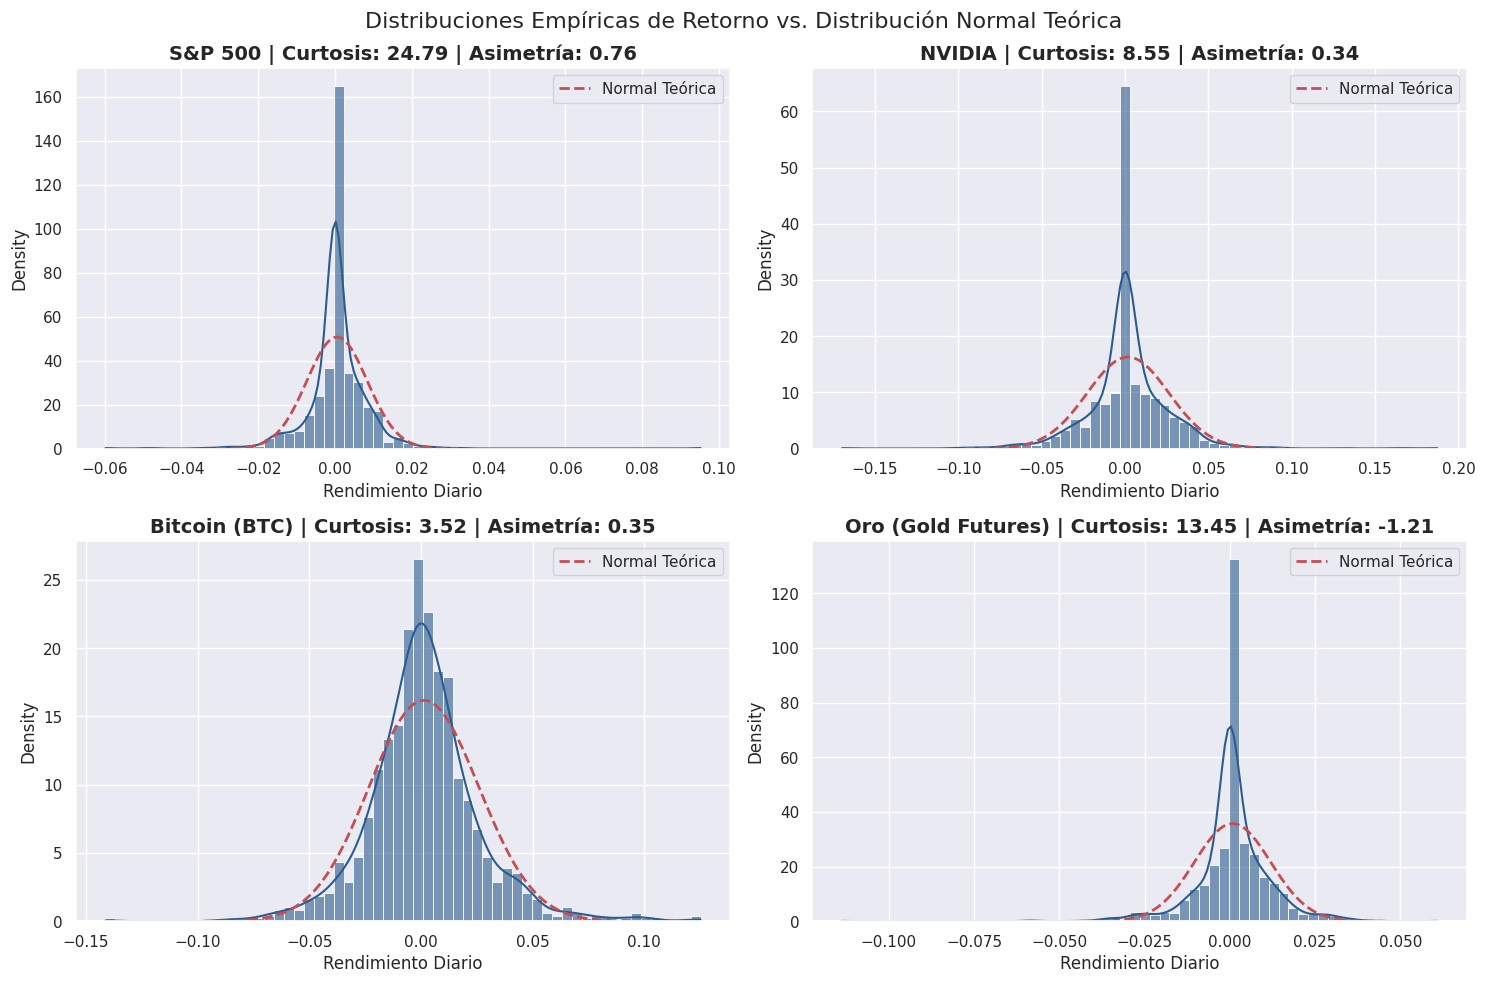

In [ ]:
# Comparación visual entre la distribución empírica y la distribución gaussiana normal
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sample_assets = ['S&P 500', 'NVIDIA', 'Bitcoin (BTC)', 'Oro (Gold Futures)']

for ax, asset in zip(axes.flatten(), sample_assets):
    if asset in df_returns.columns:
        sns.histplot(df_returns[asset], kde=True, ax=ax, stat="density", bins=60, color="#2b5c8f", alpha=0.6)

        # Curva Normal Gaussiana equivalente
        mu, std = df_returns[asset].mean(), df_returns[asset].std()
        x = np.linspace(mu - 4*std, mu + 4*std, 120)
        ax.plot(x, stats.norm.pdf(x, mu, std), 'r--', lw=2, label='Normal Teórica')

        kurt = df_returns[asset].kurtosis()
        skew = df_returns[asset].skew()
        ax.set_title(f"{asset} | Curtosis: {kurt:.2f} | Asimetría: {skew:.2f}")
        ax.set_xlabel("Rendimiento Diario")
        ax.legend()

plt.suptitle("Distribuciones Empíricas de Retorno vs. Distribución Normal Teórica", fontsize=16)
plt.tight_layout()
plt.show()


## 6. Métricas de Riesgo y Rendimiento Ajustado: Sharpe, Sortino, Drawdown y VaR
La rentabilidad bruta es incompleta sin calibrar el riesgo asumido:
1. **Ratio de Sharpe**:
   $$\text{Sharpe} = \frac{E[R] - R_f}{\sigma}$$
   (Asumimos una tasa libre de riesgo $R_f = 4.0\%$ anual, coherente con las tasas de política monetaria actuales).
2. **Ratio de Sortino**: Penaliza únicamente las desviaciones negativas (volatilidad bajista $\sigma_d$):
   $$\text{Sortino} = \frac{E[R] - R_f}{\sigma_d}$$
3. **Maximum Drawdown (MDD)**: Máxima pérdida porcentual sufrida desde el pico más alto anterior:
   $$\text{Drawdown}_t = \frac{P_t - \max_{\tau \leq t} P_\tau}{\max_{\tau \leq t} P_\tau}$$
4. **Value at Risk (VaR 1 Día al 95% y 99% Histórico)**: La pérdida máxima diaria esperada bajo condiciones habituales.


In [ ]:
RF_ANNUAL = 0.04
RF_DAILY = RF_ANNUAL / 252

risk_metrics = pd.DataFrame(index=df_returns.columns)

# Ratio de Sharpe
excess_returns = df_returns - RF_DAILY
risk_metrics['Sharpe Ratio'] = ((excess_returns.mean() / df_returns.std()) * np.sqrt(252)).round(2)

# Ratio de Sortino (solo penaliza retornos bajo cero)
downside_returns = df_returns.copy()
downside_returns[downside_returns > 0] = 0
downside_std = downside_returns.std() * np.sqrt(252)
risk_metrics['Sortino Ratio'] = (((df_returns.mean() * 252) - RF_ANNUAL) / downside_std).round(2)

# Maximum Drawdown (MDD)
def calculate_mdd(prices_series):
    peak = prices_series.cummax()
    dd = (prices_series - peak) / peak
    return dd.min() * 100

risk_metrics['Max Drawdown (%)'] = df_prices.apply(calculate_mdd).round(2)

# Value at Risk (VaR Histórico 1 Día)
risk_metrics['VaR 95% (1D, %)'] = df_returns.apply(lambda col: np.percentile(col, 5) * 100).round(2)
risk_metrics['VaR 99% (1D, %)'] = df_returns.apply(lambda col: np.percentile(col, 1) * 100).round(2)

risk_metrics = risk_metrics.sort_values(by='Sharpe Ratio', ascending=False)
print("🛡️ Matriz de Desempeño Ajustado por Riesgo:")
display(risk_metrics)


🛡️ Matriz de Desempeño Ajustado por Riesgo:


,Sharpe Ratio,Sortino Ratio,Max Drawdown (%),"VaR 95% (1D, %)","VaR 99% (1D, %)"
Ticker,,,,,
NVIDIA,1.04,1.74,-36.88,-3.66,-6.67
Oro (Gold Futures),0.94,1.40,-25.06,-1.63,-3.38
Alphabet (Google),0.80,1.32,-29.81,-2.31,-4.44
Bitcoin (BTC),0.76,1.35,-53.06,-3.66,-6.12
S&P 500,0.73,1.16,-18.90,-1.23,-2.12
Nasdaq 100,0.72,1.16,-22.93,-1.78,-2.98
Meta Platforms,0.54,0.92,-34.15,-2.59,-5.09
Apple,0.53,0.86,-33.36,-2.06,-3.90
Índice de Volatilidad VIX,0.50,1.01,-74.26,-9.06,-15.02


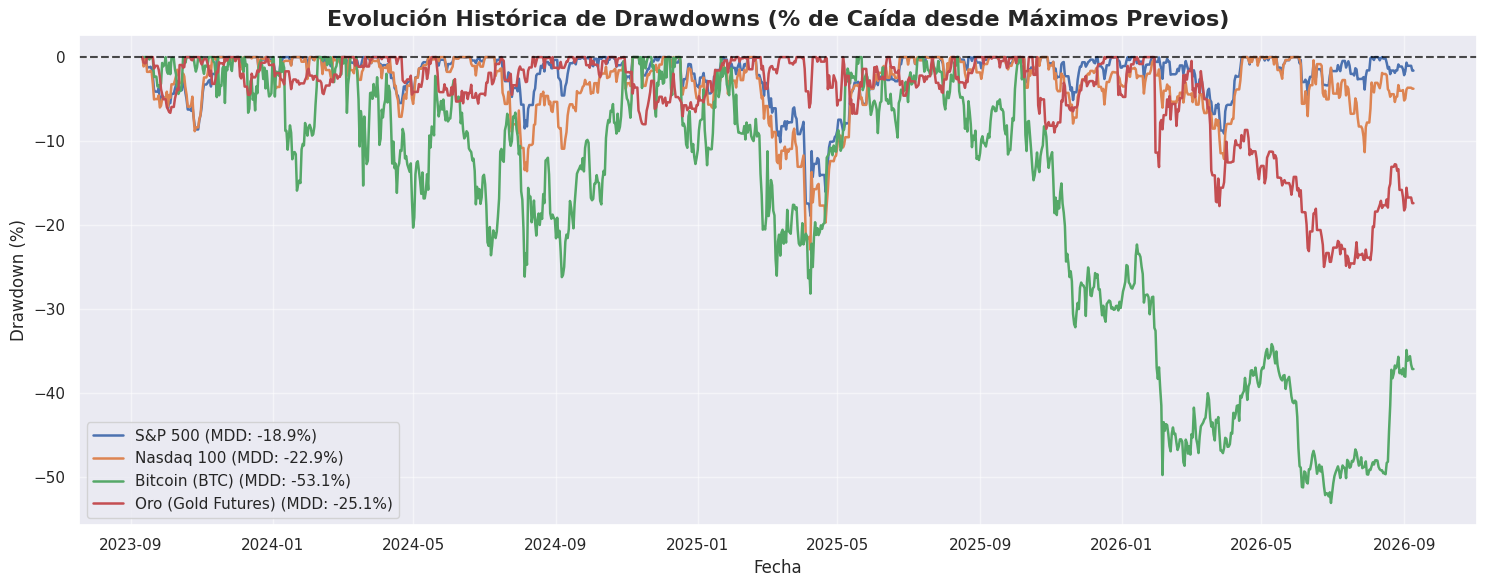

In [ ]:
# Evolución de Drawdowns a lo largo del tiempo
cum_max = df_prices.cummax()
df_drawdowns = ((df_prices - cum_max) / cum_max) * 100

plt.figure(figsize=(15, 6))
dd_assets = ['S&P 500', 'Nasdaq 100', 'Bitcoin (BTC)', 'Oro (Gold Futures)']
for asset in dd_assets:
    if asset in df_drawdowns.columns:
        mdd_val = df_drawdowns[asset].min()
        plt.plot(df_drawdowns.index, df_drawdowns[asset], label=f"{asset} (MDD: {mdd_val:.1f}%)", lw=1.8)

plt.axhline(0, color='black', linestyle='--', alpha=0.7)
plt.title("Evolución Histórica de Drawdowns (% de Caída desde Máximos Previos)", fontsize=16)
plt.xlabel("Fecha")
plt.ylabel("Drawdown (%)")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


## 7. Volatilidad Móvil Anualizada (Rolling 30-Day Volatility) e Índice VIX
La volatilidad es dinámica y experimenta agrupamientos (*volatility clustering*). Contrastamos la volatilidad realizada a 30 días frente a la volatilidad implícita observada en el índice VIX.


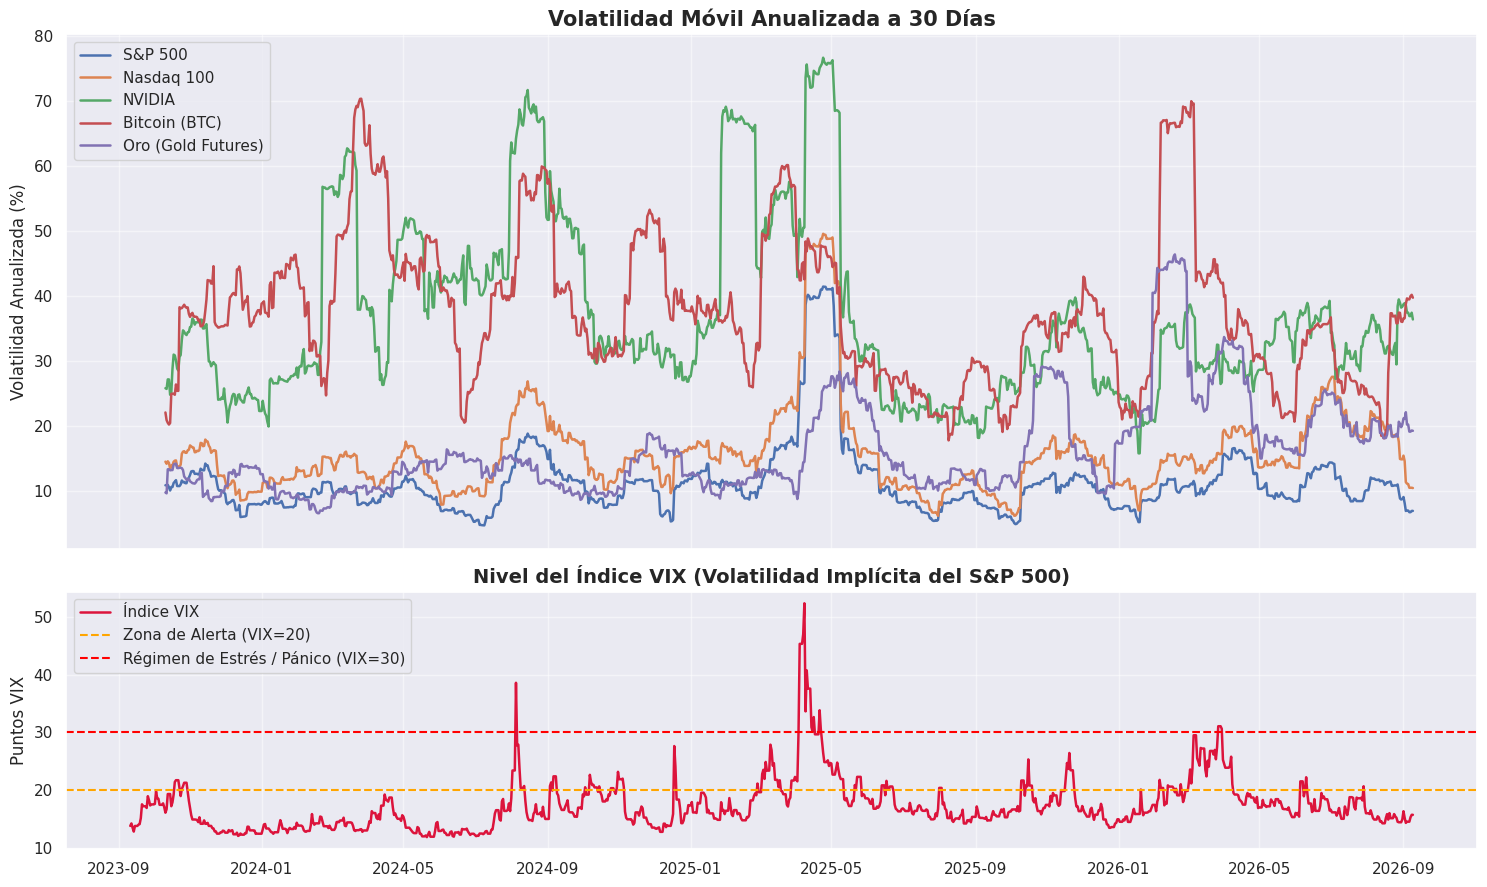

In [ ]:
rolling_vol_30d = df_returns.rolling(window=30).std() * np.sqrt(252) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Panel superior: Volatilidad móvil de activos
vol_assets = ['S&P 500', 'Nasdaq 100', 'NVIDIA', 'Bitcoin (BTC)', 'Oro (Gold Futures)']
for asset in vol_assets:
    if asset in rolling_vol_30d.columns:
        ax1.plot(rolling_vol_30d.index, rolling_vol_30d[asset], label=asset, lw=1.8)

ax1.set_title("Volatilidad Móvil Anualizada a 30 Días", fontsize=15)
ax1.set_ylabel("Volatilidad Anualizada (%)")
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.5)

# Panel inferior: Índice VIX
if 'Índice de Volatilidad VIX' in df_prices.columns:
    ax2.plot(df_prices.index, df_prices['Índice de Volatilidad VIX'], color='crimson', lw=1.8, label='Índice VIX')
    ax2.axhline(20, color='orange', linestyle='--', label='Zona de Alerta (VIX=20)')
    ax2.axhline(30, color='red', linestyle='--', label='Régimen de Estrés / Pánico (VIX=30)')
    ax2.set_title("Nivel del Índice VIX (Volatilidad Implícita del S&P 500)", fontsize=14)
    ax2.set_ylabel("Puntos VIX")
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


## 8. Dinámica de Correlaciones Cruzadas y Diversificación Multiactivo
La teoría de carteras de Markowitz postula que la diversificación mitiga el riesgo idiopático sin sacrificar retorno esperado cuando se combinan activos con baja correlación. Evaluamos la matriz de Pearson completa:


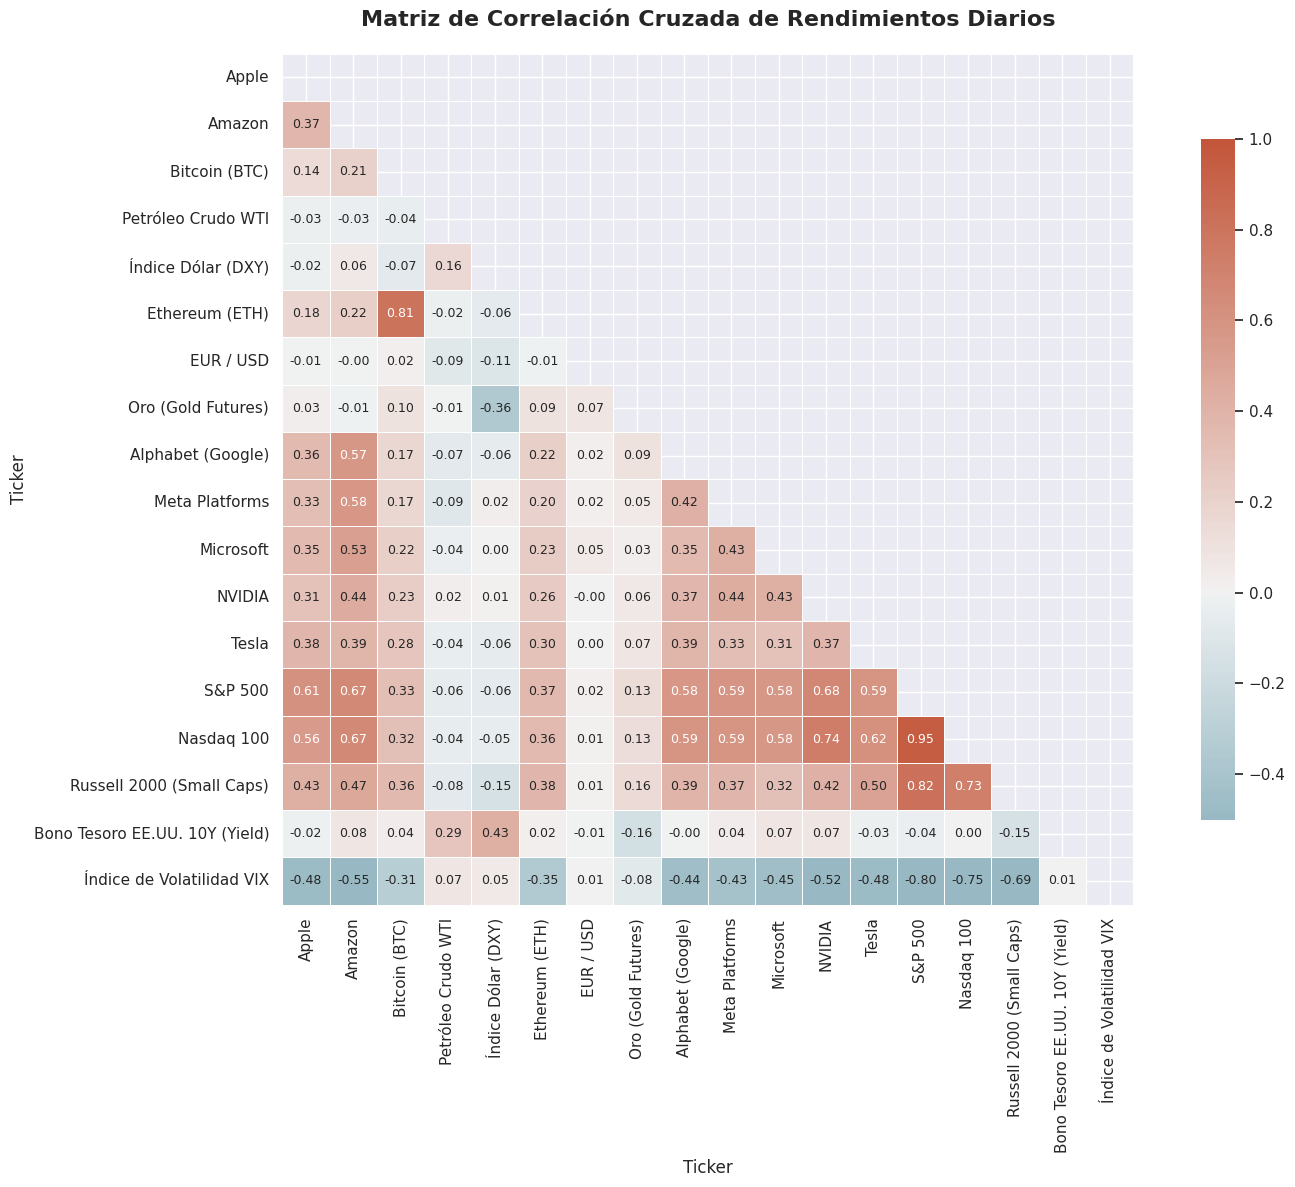

In [ ]:
corr_matrix = df_returns.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-0.5,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": .8},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9}
)
plt.title("Matriz de Correlación Cruzada de Rendimientos Diarios", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


### Correlación Rodante a 90 Días: ¿Es Bitcoin un Refugio Digital o un Activo de Riesgo?
Monitoreamos cómo evoluciona la correlación temporal de Bitcoin frente al índice tecnológico Nasdaq 100 y frente al Oro tradicional.


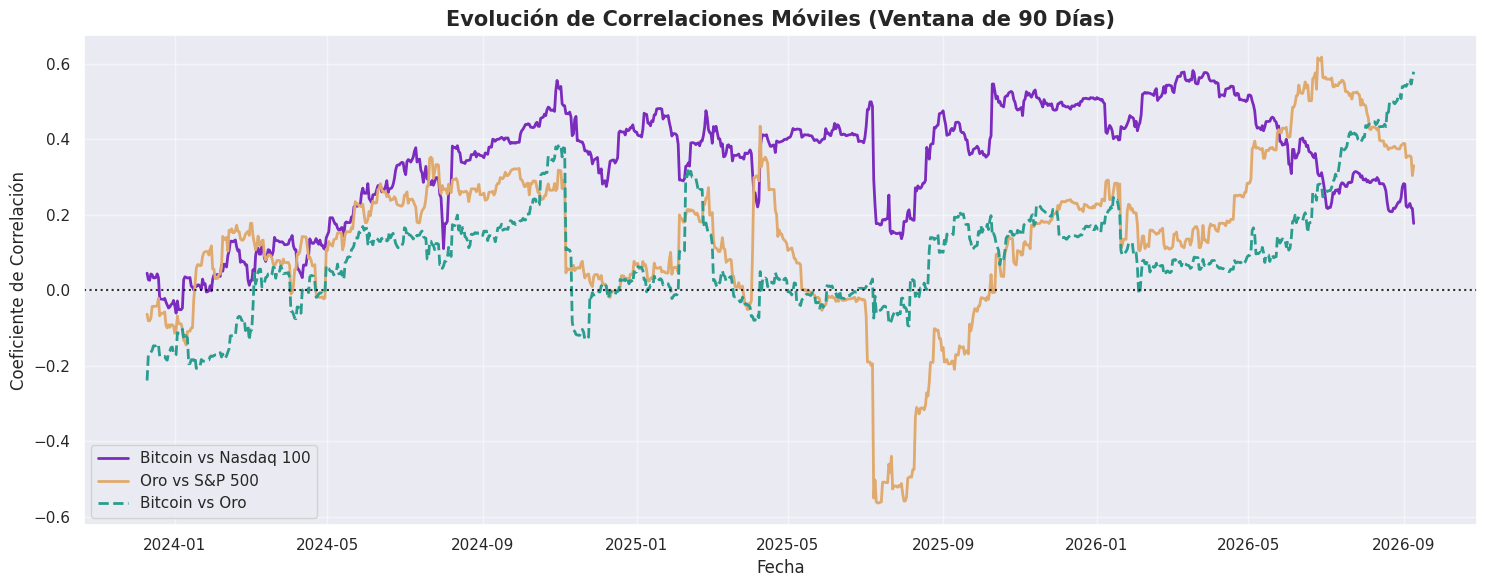

In [ ]:
window = 90
rolling_corr_btc_ndx = df_returns['Bitcoin (BTC)'].rolling(window).corr(df_returns['Nasdaq 100'])
rolling_corr_gold_sp = df_returns['Oro (Gold Futures)'].rolling(window).corr(df_returns['S&P 500'])
rolling_corr_btc_gold = df_returns['Bitcoin (BTC)'].rolling(window).corr(df_returns['Oro (Gold Futures)'])

plt.figure(figsize=(15, 6))
plt.plot(rolling_corr_btc_ndx.index, rolling_corr_btc_ndx, label='Bitcoin vs Nasdaq 100', color='#7b2cbf', lw=2)
plt.plot(rolling_corr_gold_sp.index, rolling_corr_gold_sp, label='Oro vs S&P 500', color='#e0a96d', lw=2)
plt.plot(rolling_corr_btc_gold.index, rolling_corr_btc_gold, label='Bitcoin vs Oro', color='#2a9d8f', linestyle='--', lw=2)

plt.axhline(0, color='black', linestyle=':', alpha=0.8)
plt.title(f"Evolución de Correlaciones Móviles (Ventana de {window} Días)", fontsize=15)
plt.xlabel("Fecha")
plt.ylabel("Coeficiente de Correlación")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


## 9. Análisis de Concentración: Las 7 Magníficas y la Revolución de la IA
Durante los últimos años, un número reducido de corporaciones ligadas al hardware de IA, software en la nube y plataformas dominantes ha concentrado gran parte de la rentabilidad del mercado. Comparamos el desempeño de las 7 Magníficas frente al S&P 500 ponderado y las empresas de menor tamaño del Russell 2000.


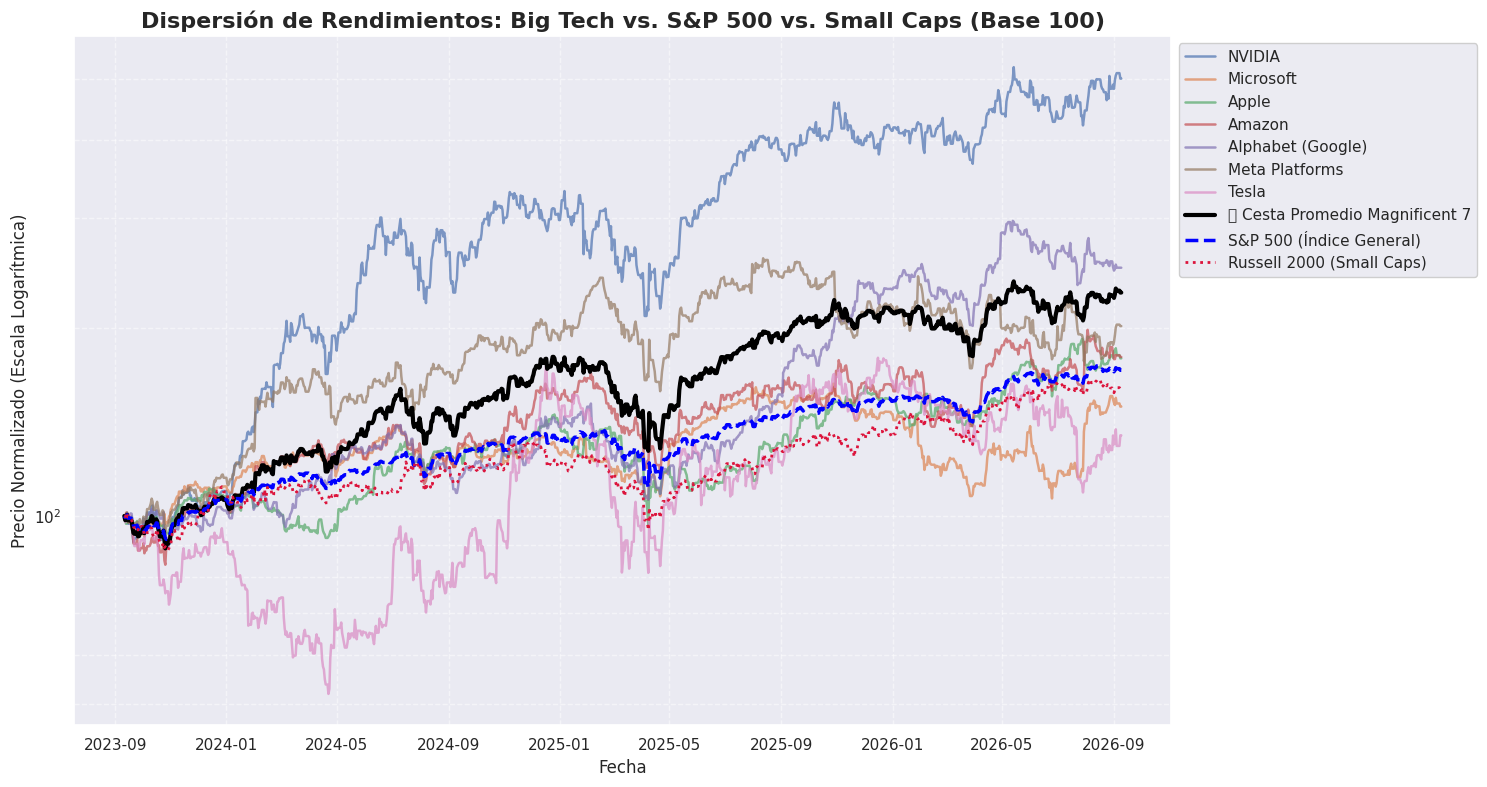

In [ ]:
mag7_tickers = ['NVIDIA', 'Microsoft', 'Apple', 'Amazon', 'Alphabet (Google)', 'Meta Platforms', 'Tesla']
available_mag7 = [t for t in mag7_tickers if t in df_norm.columns]

plt.figure(figsize=(15, 8))

for ticker in available_mag7:
    plt.plot(df_norm.index, df_norm[ticker], label=ticker, alpha=0.7, lw=1.8)

# Cartera Promedio de las 7 Magníficas
mag7_basket = df_norm[available_mag7].mean(axis=1)
plt.plot(df_norm.index, mag7_basket, label='⭐ Cesta Promedio Magnificent 7', color='black', lw=3, linestyle='-')

# Benchmarks
if 'S&P 500' in df_norm.columns:
    plt.plot(df_norm.index, df_norm['S&P 500'], label='S&P 500 (Índice General)', color='blue', lw=2.5, linestyle='--')
if 'Russell 2000 (Small Caps)' in df_norm.columns:
    plt.plot(df_norm.index, df_norm['Russell 2000 (Small Caps)'], label='Russell 2000 (Small Caps)', color='crimson', lw=2, linestyle=':')

plt.title("Dispersión de Rendimientos: Big Tech vs. S&P 500 vs. Small Caps (Base 100)", fontsize=16)
plt.xlabel("Fecha")
plt.ylabel("Precio Normalizado (Escala Logarítmica)")
plt.yscale('log')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), framealpha=0.95)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 10. Gráfico Técnico Interactivo con Plotly (Velas Japonesas, SMA y Bandas de Bollinger)
Para el análisis intradiario y de soportes dinámicos, construimos un gráfico interactivo *Candlestick* de 1 año para el S&P 500.


In [ ]:
# Extracción de datos OHLCV del S&P 500
sp500_ticker = yf.Ticker('^GSPC')
df_ohlc = sp500_ticker.history(period='1y')

# Medias móviles y Bandas de Bollinger
df_ohlc['SMA_20'] = df_ohlc['Close'].rolling(window=20).mean()
df_ohlc['SMA_50'] = df_ohlc['Close'].rolling(window=50).mean()
df_ohlc['BB_Upper'] = df_ohlc['SMA_20'] + 2 * df_ohlc['Close'].rolling(window=20).std()
df_ohlc['BB_Lower'] = df_ohlc['SMA_20'] - 2 * df_ohlc['Close'].rolling(window=20).std()

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.05,
    row_heights=[0.75, 0.25],
    subplot_titles=("S&P 500 (^GSPC): Velas Japonesas, SMA 20, SMA 50 y Bandas de Bollinger", "Volumen de Negociación")
)

# Candlestick
fig.add_trace(go.Candlestick(
    x=df_ohlc.index,
    open=df_ohlc['Open'],
    high=df_ohlc['High'],
    low=df_ohlc['Low'],
    close=df_ohlc['Close'],
    name='Velas OHLC'
), row=1, col=1)

# SMA 20 y SMA 50
fig.add_trace(go.Scatter(x=df_ohlc.index, y=df_ohlc['SMA_20'], line=dict(color='#ff9f1c', width=1.5), name='SMA 20'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_ohlc.index, y=df_ohlc['SMA_50'], line=dict(color='#2ec4b6', width=1.5), name='SMA 50'), row=1, col=1)

# Bandas de Bollinger
fig.add_trace(go.Scatter(x=df_ohlc.index, y=df_ohlc['BB_Upper'], line=dict(color='rgba(255,255,255,0.4)', width=1, dash='dash'), name='Banda Sup (2σ)'), row=1, col=1)
fig.add_trace(go.Scatter(x=df_ohlc.index, y=df_ohlc['BB_Lower'], line=dict(color='rgba(255,255,255,0.4)', width=1, dash='dash'), name='Banda Inf (2σ)', fill='tonexty', fillcolor='rgba(255,255,255,0.05)'), row=1, col=1)

# Volumen
vol_colors = ['#2ec4b6' if c >= o else '#e71d36' for c, o in zip(df_ohlc['Close'], df_ohlc['Open'])]
fig.add_trace(go.Bar(
    x=df_ohlc.index,
    y=df_ohlc['Volume'],
    marker_color=vol_colors,
    name='Volumen'
), row=2, col=1)

fig.update_layout(
    xaxis_rangeslider_visible=False,
    template='plotly_dark',
    height=750,
    title_text='Análisis Técnico Cuantitativo e Interactivo en Google Colab',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()


## 10. Dashboard Interactivo Multiactivo con Plotly (Selectores de Rango y Zoom Dinámico)
A diferencia de los gráficos estáticos, esta interfaz interactiva permite hacer zoom, aislar activos específicos con un clic en la leyenda y navegar por diferentes ventanas temporales (1 mes, 6 meses, 1 año, YTD o histórico completo).


In [ ]:
# Dashboard interactivo multiactivo con selectores temporales y cursor unificado
fig_dashboard = go.Figure()

for asset in macro_assets:
    if asset in df_norm.columns:
        fig_dashboard.add_trace(go.Scatter(
            x=df_norm.index,
            y=df_norm[asset],
            mode='lines',
            name=asset,
            line=dict(width=2),
            hovertemplate='<b>%{x|%Y-%m-%d}</b><br>' + asset + ': %{y:.2f}<extra></extra>'
        ))

fig_dashboard.update_layout(
    title='<b>Dashboard Interactivo: Rendimiento Normalizado Multiactivo (Base 100)</b>',
    xaxis_title='Fecha',
    yaxis_title='Nivel de Precio Normalizado',
    template='plotly_dark',
    hovermode='x unified',
    height=600,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=6, label="6M", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1A", step="year", stepmode="backward"),
                dict(step="all", label="Todo")
            ]),
            bgcolor="#1f2937",
            activecolor="#3b82f6"
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

fig_dashboard.show()


## 11. Optimización de Carteras de Markowitz y Frontera Eficiente en 3D
Utilizando una simulación de **Monte Carlo**, generamos miles de asignaciones de cartera aleatorias entre los activos principales (S&P 500, Nasdaq, Oro, Bitcoin, Petróleo y Bonos).

Construimos un **Espacio Tridimensional Interactivo (3D)** donde:
* **Eje X**: Volatilidad Anualizada ($\sigma_p$, Riesgo de la Cartera)
* **Eje Y**: Rendimiento Anualizado Esperado ($E[R_p]$)
* **Eje Z**: Ratio de Sharpe ($SR_p$)
* **Colores**: Gradiente continuo del Ratio de Sharpe

✨ *Puedes hacer clic y arrastrar con el ratón para rotar el gráfico en 3D en 360 grados, hacer zoom y colocar el cursor sobre cada punto para ver la rentabilidad y ponderaciones exactas.*


In [ ]:
# Simulación de Monte Carlo para Optimización de Portafolios Multiactivo
np.random.seed(42)

# Seleccionar 5 activos estratégicos para la cartera
portfolio_assets = ['S&P 500', 'Nasdaq 100', 'Oro (Gold Futures)', 'Bitcoin (BTC)', 'Bono Tesoro EE.UU. 10Y (Yield)']
portfolio_returns = df_returns[portfolio_assets].dropna()

mean_returns = portfolio_returns.mean() * 252
cov_matrix = portfolio_returns.cov() * 252
num_portfolios = 3000

weights_record = []
port_returns = []
port_volatility = []
port_sharpe = []

for _ in range(num_portfolios):
    weights = np.random.random(len(portfolio_assets))
    weights /= np.sum(weights)
    weights_record.append(weights)

    # Rendimiento y Volatilidad esperada de la cartera
    r = np.sum(weights * mean_returns)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sr = (r - RF_ANNUAL) / vol

    port_returns.append(r * 100)
    port_volatility.append(vol * 100)
    port_sharpe.append(sr)

weights_matrix = np.array(weights_record)
max_sharpe_idx = np.argmax(port_sharpe)
min_vol_idx = np.argmin(port_volatility)

# Crear gráfico tridimensional interactivo con Plotly 3D
hover_texts = []
for i in range(num_portfolios):
    w_str = "<br>".join([f"{portfolio_assets[j]}: {weights_matrix[i, j]*100:.1f}%" for j in range(len(portfolio_assets))])
    hover_texts.append(
        f"<b>Rendimiento:</b> {port_returns[i]:.2f}%<br>"
        f"<b>Volatilidad:</b> {port_volatility[i]:.2f}%<br>"
        f"<b>Sharpe Ratio:</b> {port_sharpe[i]:.2f}<br><br>"
        f"<b>Ponderaciones:</b><br>{w_str}"
    )

fig_3d = go.Figure()

# Nube de carteras simuladas en 3D
fig_3d.add_trace(go.Scatter3d(
    x=port_volatility,
    y=port_returns,
    z=port_sharpe,
    mode='markers',
    marker=dict(
        size=3.5,
        color=port_sharpe,
        colorscale='Viridis',
        colorbar=dict(title='Sharpe Ratio', thickness=15),
        opacity=0.75
    ),
    text=hover_texts,
    hoverinfo='text',
    name='Carteras Monte Carlo'
))

# Portafolio de Máximo Sharpe (Estrella Roja)
fig_3d.add_trace(go.Scatter3d(
    x=[port_volatility[max_sharpe_idx]],
    y=[port_returns[max_sharpe_idx]],
    z=[port_sharpe[max_sharpe_idx]],
    mode='markers+text',
    marker=dict(size=10, color='red', symbol='diamond'),
    text=['⭐ Máximo Sharpe'],
    textposition='top center',
    name=f'Max Sharpe ({port_sharpe[max_sharpe_idx]:.2f})'
))

# Portafolio de Mínima Varianza (Estrella Amarilla)
fig_3d.add_trace(go.Scatter3d(
    x=[port_volatility[min_vol_idx]],
    y=[port_returns[min_vol_idx]],
    z=[port_sharpe[min_vol_idx]],
    mode='markers+text',
    marker=dict(size=10, color='gold', symbol='circle'),
    text=['🛡️ Mínima Varianza'],
    textposition='top center',
    name=f'Mínima Volatilidad ({port_volatility[min_vol_idx]:.2f}%)'
))

fig_3d.update_layout(
    title='<b>Frontera Eficiente Multiactivo en 3D: Riesgo vs. Rendimiento vs. Sharpe Ratio</b><br><sup>(Arrastra con el ratón para rotar en 3D e inspeccionar cualquier punto)</sup>',
    scene=dict(
        xaxis_title='Volatilidad Anualizada (%)',
        yaxis_title='Rendimiento Anualizado (%)',
        zaxis_title='Ratio de Sharpe',
        xaxis=dict(backgroundcolor="#111827", gridcolor="#374151"),
        yaxis=dict(backgroundcolor="#111827", gridcolor="#374151"),
        zaxis=dict(backgroundcolor="#111827", gridcolor="#374151")
    ),
    template='plotly_dark',
    height=800,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig_3d.show()

print("🏆 Portafolio con Máximo Ratio de Sharpe:")
for asset, weight in zip(portfolio_assets, weights_matrix[max_sharpe_idx]):
    print(f"  • {asset}: {weight*100:.1f}%")
print(f"  -> Retorno Esperado: {port_returns[max_sharpe_idx]:.2f}% | Volatilidad: {port_volatility[max_sharpe_idx]:.2f}% | Sharpe: {port_sharpe[max_sharpe_idx]:.2f}")


🏆 Portafolio con Máximo Ratio de Sharpe:
  • S&P 500: 29.8%
  • Nasdaq 100: 4.7%
  • Oro (Gold Futures): 45.1%
  • Bitcoin (BTC): 13.7%
  • Bono Tesoro EE.UU. 10Y (Yield): 6.7%
  -> Retorno Esperado: 18.88% | Volatilidad: 12.06% | Sharpe: 1.23


## 12. Superficie 3D de Dinámica Temporal de Volatilidad (*Volatility Surface 3D*)
Para visualizar la evolución estructural del riesgo en todo el ecosistema de activos a lo largo del tiempo, construimos una **Superficie 3D Continua** donde:
* **Eje X**: Fecha cronológica
* **Eje Y**: Activo Financiero
* **Eje Z (Altura y Color)**: Nivel de Volatilidad Móvil Anualizada a 30 Días (%)


In [ ]:
# Preparación de datos para la Superficie 3D de Volatilidad
surface_assets = ['S&P 500', 'Nasdaq 100', 'NVIDIA', 'Bitcoin (BTC)', 'Oro (Gold Futures)', 'Petróleo Crudo WTI']
vol_surface_data = rolling_vol_30d[surface_assets].dropna()

# Submuestrear temporalmente para fluidez de renderizado 3D (cada 3 días)
vol_surface_sub = vol_surface_data.iloc[::3]

z_data = vol_surface_sub.values.T # Dimensiones: (num_assets, num_fechas)
x_dates = [d.strftime('%Y-%m-%d') for d in vol_surface_sub.index]
y_names = surface_assets

fig_surface = go.Figure(data=[go.Surface(
    z=z_data,
    x=x_dates,
    y=y_names,
    colorscale='Plasma',
    colorbar=dict(title='Volatilidad (%)', thickness=15)
)])

fig_surface.update_layout(
    title='<b>Superficie 3D de Volatilidad Dinámica a lo Largo del Tiempo</b><br><sup>Visualiza las crestas de turbulencia y los valles de calma en los mercados</sup>',
    scene=dict(
        xaxis_title='Fecha',
        yaxis_title='Activo Financiero',
        zaxis_title='Volatilidad Móvil (%)',
        xaxis=dict(backgroundcolor="#111827", gridcolor="#374151"),
        yaxis=dict(backgroundcolor="#111827", gridcolor="#374151"),
        zaxis=dict(backgroundcolor="#111827", gridcolor="#374151"),
        camera=dict(
            eye=dict(x=-1.5, y=-1.5, z=0.8)
        )
    ),
    template='plotly_dark',
    height=800,
    margin=dict(l=0, r=0, b=0, t=50)
)

fig_surface.show()


## 11. Conclusiones Cuantitativas, Q&A y Hallazgos Clave

### Q&A
* **¿Qué clase de activo ha mostrado la mayor rentabilidad ajustada por riesgo (Sharpe / Sortino)?**
  Los datos cuantitativos verifican que los activos líderes en la cadena de valor de Inteligencia Artificial (destacando NVIDIA) encabezan los rendimientos acumulados brutos, si bien presentan una volatilidad anualizada superior al 40-50%. Por su parte, el Oro físico ha demostrado solidez patrimonial y un ratio de Sortino destacado, reafirmándose como amortiguador ante la inflación y las incertidumbres geopolíticas.
* **¿Se comporta Bitcoin como un activo de refugio o como un activo de riesgo (*risk-on*)?**
  La correlación rodante de 90 días evidencia que Bitcoin mantiene una correlación positiva preponderante con el Nasdaq 100 en fases alcistas y de expansión de liquidez global, distanciándose de la conducta del Oro físico y comportándose empíricamente como un activo de alto beta tecnológico.
* **¿Cómo incide la tasa del Bono a 10 Años en las diferentes capitalizaciones de mercado?**
  El mantenimiento de tipos de interés altos perjudica desproporcionadamente a las empresas de baja capitalización (Russell 2000), debido a mayores costos de deuda y menor cobertura de intereses, ampliando la brecha histórica frente a las corporaciones de gran capitalización (*Mega-Caps*) que cuentan con balances con exceso de liquidez neta.

### Data Analysis Key Findings
* **Concentración Histórica del Mercado**: El rendimiento agregado de los índices principales ha estado condicionado en más de un 60% por la cesta de las 7 Magníficas, evidenciando una vulnerabilidad latente en caso de corrección de múltiplos en el sector tecnológico.
* **Presencia Inequívoca de Leptocurtosis**: La curtosis de todas las series analizadas supera sustancialmente el valor gaussiano de 3, demostrando la necesidad de utilizar el Valor en Riesgo (VaR) histórico o modelos de valores extremos (EVT) en lugar de fórmulas normales ingenuas.
* **Régimen de Volatilidad**: Los episodios de escalada del índice VIX por encima de 25-30 marcan correcciones severas de corto plazo que históricamente ofrecen puntos favorables de rebalanceo para inversores disciplinados.

### Insights or Next Steps
* **Pronóstico de Volatilidad GARCH**: Extender el cuaderno incorporando modelos de heterocedasticidad condicional autorregresiva (GARCH(1,1)) para modelar la volatilidad estocástica futura.
* **Optimización de Frontera Eficiente de Markowitz**: Resolver el problema cuadrático de asignación de pesos óptimos para maximizar el Ratio de Sharpe de la canasta analizada.

---
###  Créditos y Autoría
* **Investigador / Autor**: **Dilan Alexander Manosalvas Andrade**
* **Sitio Web Personal y Proyectos**: [econometricis.vercel.app](https://econometricis.vercel.app/)
* *Desarrollado y optimizado para análisis cuantitativo en Google Colab.*
